In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from core import find_nearest_words
from core import lookup_embedding
from core import prepare_dataset
from core import train_skipgram_embeddings

In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1]

DATA_DIR = PROJECT_ROOT / "data" / "vietnamese_food"
VOCAB_PATH = DATA_DIR / "vocab.json"
SENTENCES_PATH = DATA_DIR / "sentences.txt"
DATASET_PATH = DATA_DIR / "dataset.jsonl"
METADATA_PATH = DATA_DIR / "metadata.json"

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)

RNG_SEED = 7
EMBEDDING_DIM = 8
LEARNING_RATE = 0.1
EPOCHS = 50
WINDOW_SIZE = 1
TOP_K = 5

NOTEBOOK_DIR: /Users/khueluu/Documents/Projects/deep-learning-from-scratch/lessons/16_embeddings
PROJECT_ROOT: /Users/khueluu/Documents/Projects/deep-learning-from-scratch
DATA_DIR: /Users/khueluu/Documents/Projects/deep-learning-from-scratch/data/vietnamese_food


## Prepare dataset

In [3]:
tokens, token_to_id, sentences, training_pairs = prepare_dataset(
    vocab_path=VOCAB_PATH,
    sentences_path=SENTENCES_PATH,
    window_size=WINDOW_SIZE,
)

print("Dataset summary")
print(f"- Vocabulary size: {len(tokens)}")
print(f"- Number of sentences: {len(sentences)}")
print(f"- Number of training pairs: {len(training_pairs)}")

Dataset summary
- Vocabulary size: 112
- Number of sentences: 500
- Number of training pairs: 2246


## Train embeddings

In [4]:
embedding, _, loss_history = train_skipgram_embeddings(
    training_pairs=training_pairs,
    vocab_size=len(tokens),
    embedding_dim=EMBEDDING_DIM,
    learning_rate=LEARNING_RATE,
    epochs=EPOCHS,
    seed=RNG_SEED,
)

print("Training loss")
for epoch_idx, loss_value in enumerate(loss_history, start=1):
    print(f"Epoch {epoch_idx:02d} | avg_loss={loss_value:.4f}")
print()

Training loss
Epoch 01 | avg_loss=4.5252
Epoch 02 | avg_loss=3.6594
Epoch 03 | avg_loss=3.4110
Epoch 04 | avg_loss=3.3111
Epoch 05 | avg_loss=3.2481
Epoch 06 | avg_loss=3.1919
Epoch 07 | avg_loss=3.1472
Epoch 08 | avg_loss=3.1118
Epoch 09 | avg_loss=3.0831
Epoch 10 | avg_loss=3.0610
Epoch 11 | avg_loss=3.0449
Epoch 12 | avg_loss=3.0338
Epoch 13 | avg_loss=3.0264
Epoch 14 | avg_loss=3.0215
Epoch 15 | avg_loss=3.0182
Epoch 16 | avg_loss=3.0159
Epoch 17 | avg_loss=3.0142
Epoch 18 | avg_loss=3.0131
Epoch 19 | avg_loss=3.0122
Epoch 20 | avg_loss=3.0116
Epoch 21 | avg_loss=3.0110
Epoch 22 | avg_loss=3.0106
Epoch 23 | avg_loss=3.0103
Epoch 24 | avg_loss=3.0100
Epoch 25 | avg_loss=3.0097
Epoch 26 | avg_loss=3.0095
Epoch 27 | avg_loss=3.0093
Epoch 28 | avg_loss=3.0091
Epoch 29 | avg_loss=3.0089
Epoch 30 | avg_loss=3.0087
Epoch 31 | avg_loss=3.0085
Epoch 32 | avg_loss=3.0083
Epoch 33 | avg_loss=3.0081
Epoch 34 | avg_loss=3.0079
Epoch 35 | avg_loss=3.0077
Epoch 36 | avg_loss=3.0075
Epoch 37 | avg

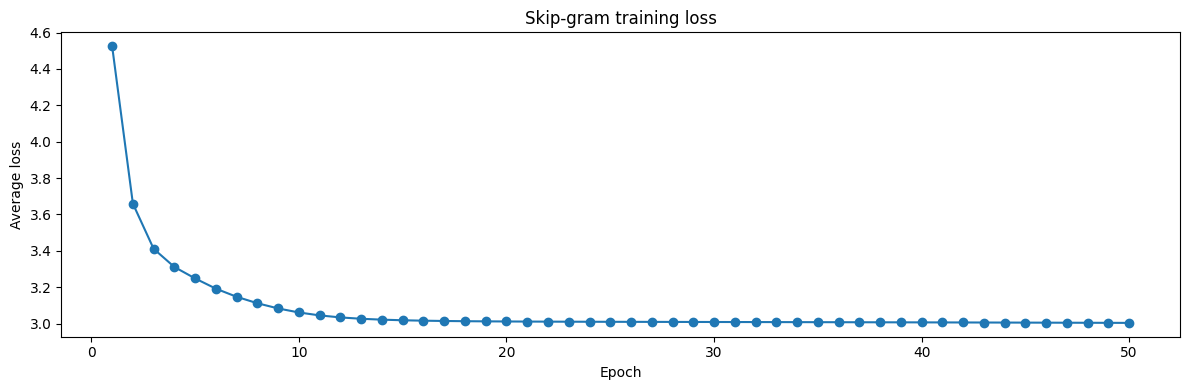

In [5]:
epochs = np.arange(1, len(loss_history) + 1)

plt.figure(figsize=(12, 4))
plt.plot(epochs, loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average loss")
plt.title("Skip-gram training loss")
plt.tight_layout()
plt.show()

## Embedding lookup

In [6]:
words=["phở", "bún", "cà phê sữa", "nước mắm"]

for word in words:
    word_id = token_to_id[word]
    vector = lookup_embedding(
        word=word,
        token_to_id=token_to_id,
        embedding=embedding,
    )
    print(f"Word: {word}")
    print(f"ID: {word_id}")
    print(f"Vector: {np.round(vector, 4)}")

Word: phở
ID: 4
Vector: [-0.0922 -0.3759  0.0779 -0.8042 -0.168  -0.8854 -1.0246  0.1165]
Word: bún
ID: 5
Vector: [ 1.3835 -0.1033  0.2077 -0.8057 -0.3018 -0.0913 -1.3082 -0.3461]
Word: cà phê sữa
ID: 22
Vector: [-0.1919 -2.024  -0.1453  0.3069  0.1085  0.6066  1.1041  0.4686]
Word: nước mắm
ID: 64
Vector: [ 1.1666  1.8281  0.5315 -2.3867 -0.0619 -2.6181 -2.1647 -1.2806]


## Find nearest neighbours

In [7]:
query_words=["phở", "cà phê sữa", "bò"]

for query_word in query_words:
    print(f"Nearest words to '{query_word}':")
    neighbors = find_nearest_words(
        query_word=query_word,
        token_to_id=token_to_id,
        tokens=tokens,
        embedding=embedding,
        top_k=TOP_K,
    )
    for word, score in neighbors:
        print(f"  {word:12s} cosine={score:.4f}")

Nearest words to 'phở':
  bánh chưng   cosine=0.7987
  xôi          cosine=0.7923
  họ           cosine=0.7795
  chúng tôi    cosine=0.7635
  bạn          cosine=0.7536
Nearest words to 'cà phê sữa':
  sữa đậu nành cosine=0.9238
  cà chua      cosine=0.8263
  cà phê       cosine=0.8236
  nước cam     cosine=0.8096
  trà chanh    cosine=0.7970
Nearest words to 'bò':
  heo          cosine=0.6492
  cà phê       cosine=0.6155
  cá           cosine=0.5759
  gà           cosine=0.5288
  cà phê sữa   cosine=0.4994


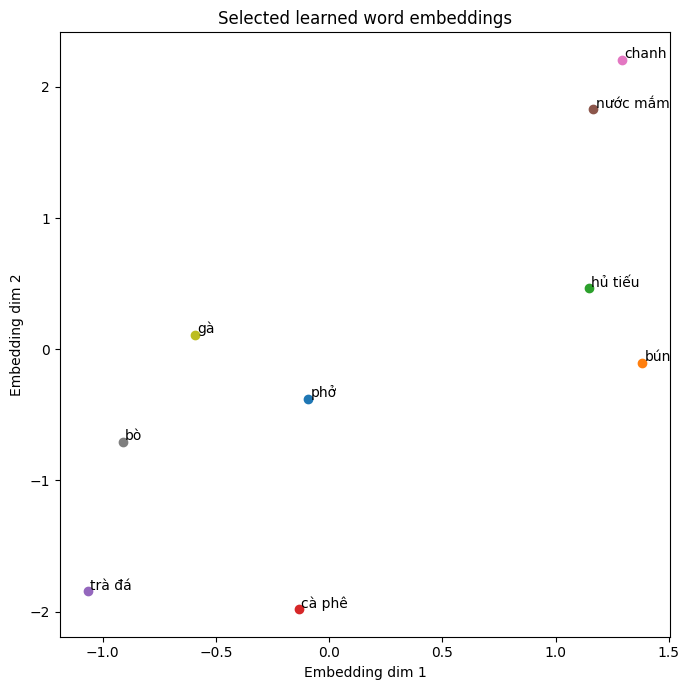

In [9]:
words=[
    "phở",
    "bún",
    "hủ tiếu",
    "cà phê",
    "trà đá",
    "nước mắm",
    "chanh",
    "bò",
    "gà",
]

plt.figure(figsize=(7, 7))

for word in words:
    vector = lookup_embedding(
        word=word,
        token_to_id=token_to_id,
        embedding=embedding,
    )
    x_coord = vector[0]
    y_coord = vector[1]
    plt.scatter(x_coord, y_coord)
    plt.text(x_coord + 0.01, y_coord + 0.01, word, fontsize=10)

plt.xlabel("Embedding dim 1")
plt.ylabel("Embedding dim 2")
plt.title("Selected learned word embeddings")
plt.tight_layout()
plt.show()